# Koopman Operator Training with Autoencoder

This notebook implements a training pipeline for a Koopman operator model combined with an autoencoder. The code includes data loading, model definition, training, and visualization of results such as trajectories and eigenvalues.


In [1]:
import os
# Move up one directory to make sure the script can find the modules and save files in the correct place
os.chdir('..')
# Verify the current working directory
print(os.getcwd())

import argparse
import json
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, Dataset
import torch.nn.init as init
import torch.multiprocessing as mp
import torch.nn as nn

# Import local modules (assuming these are available in your environment)
from utils.tools import set_seed, get_device
from utils.config_args import get_args
from utils.Viz import *
from KoopmanTrainer import Trainer 
from KoopmanTrainer_AFT import Trainer as Trainer_AFT
from data_handler import KoopmanDataHandler
from models.autoencoder import AutoEncoder
from models.koopman_operator import Knet
#from models.AFT import AttentionFreeTransformer

# Set multiprocessing start method
try:
    mp.set_start_method('spawn')
except RuntimeError:
    pass  # method already set

# Disable deterministic algorithms for flexibility
torch.use_deterministic_algorithms(False)


/Users/mohammedahmed/Desktop/Project/KoopKAN/Clean Code/bio-koopman-autoencoder


In [2]:
import torch
import torch.nn as nn

class AttentionFreeTransformer(nn.Module):
    def __init__(self, d_model, max_seq_len, device):
        super().__init__()
        self.d_model = d_model
        self.device = device
        self.max_seq_len = max_seq_len

        self.Wq = nn.Linear(d_model, d_model)
        self.Wk = nn.Linear(d_model, d_model)
        self.Wv = nn.Linear(d_model, d_model)

        self.position_bias = nn.Parameter(torch.randn(max_seq_len, max_seq_len))
        mask = torch.triu(torch.ones(max_seq_len, max_seq_len), diagonal=1).bool()
        self.register_buffer('mask', mask)

    def forward(self, x):
        """
        x: (batch, seq_len, d_model)
        Returns: (batch, d_model)  # only the last timestep
        """
        B, T, D = x.size()
        assert D == self.d_model, "Input dim mismatch"

        q = torch.sigmoid(self.Wq(x))      # (B, T, D)  
        k = self.Wk(x) / (self.d_model ** 0.5)   # (B, T, D)
        v = self.Wv(x) / (self.d_model ** 0.5)   # (B, T, D)

        w = self.position_bias[:T, :T]     # (T, T)

        k_exp = k.unsqueeze(1)             # (B, 1, T, D)
        v_exp = v.unsqueeze(1)             # (B, 1, T, D)
        w_exp = w.unsqueeze(0).unsqueeze(-1)  # (1, T, T, 1)

        k_biased = k_exp + w_exp           # (B, T, T, D)
        exp_k = torch.exp(k_biased)        # (B, T, T, D)

        m = self.mask[:T, :T]              # (T, T)
        m_exp = m.unsqueeze(0).unsqueeze(-1)  # (1, T, T, 1)
        exp_k = exp_k.masked_fill(m_exp, 0.0)

        num = (exp_k * v_exp).sum(dim=2)   # (B, T, D)
        denom = exp_k.sum(dim=2)           # (B, T, D)
        y = q * (num / (denom + 1e-8))     # (B, T, D)

        return y[:, -1, :]                 # return only last timestep

## Training Settings

Configure the training settings, including random seeds for reproducibility and device selection (CUDA or CPU).

In [3]:
# the version of pandas
def get_pandas_version():
    import numpy as np
    import pandas as pd
    return pd.__version__
print(f"Pandas version: {get_pandas_version()}")
import numpy as np
print(f"NumPy version: {np.__version__}")

Pandas version: 2.2.2
NumPy version: 2.0.1


In [4]:
# Get arguments (assuming get_args() handles command-line or default args)
args = get_args()

# Set seeds for reproducibility
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.cuda.manual_seed(args.seed)
torch.manual_seed(args.seed)
np.random.seed(args.seed)
set_seed(args.seed)

# Device configuration
device = get_device()

Using the CPU


In [5]:
# editing the args 
# in this experiement we increased the timesteps to 201 and the time to 40 which is double the original experiment to make sure we would capture the limit cycle 
args.dataset = 'isolated_repressilator'
args.folder = 'isolated_repressilator_AFT_n1.60'
args.time_steps = 201
args.prediction_length = 200
args.max_time = 250
args.num_samples = 15000
args.bottleneck = 100
args.decoder_loss_weight = 1
args.lr = 1e-3
args.epochs = 100
args.loss_function = 'mse'
args.unitary_loss_weight = 10
args.save = True
args.data_parameters = [0.03, 10, 40, 1.60, 0.3466, 0.0693, 10]


## Create Experiment Folder

Set up the folder structure to save experiment results, including arguments in a JSON file.

In [6]:
# Create experiment folder
experiment_folder = 'experiments'
if not os.path.isdir(experiment_folder):
    os.mkdir(experiment_folder)

folder_path = os.path.join(experiment_folder, args.folder)
os.makedirs(folder_path, exist_ok=True)

# Save arguments to JSON
args_dict = vars(args)
with open(os.path.join(folder_path, 'args.json'), 'w') as f:
    json.dump(args_dict, f,indent=2)

## Load and Prepare Dataset

Load and preprocess the dataset using the `KoopmanDataHandler` class, then create data loaders for training, validation, and testing.

In [7]:
# Convert args to a dictionary for the data handler

config = {
    "dataset": args.dataset,
    "data_dir": args.data_dir,
    "train_size": args.train_size,
    "val_size": args.val_size,
    "batch_size": args.batch_size,
    "noise": args.noise,
    "orthogonal_projection": args.orthogonal_projection,
    "num_combinations": args.num_combinations,
    "num_samples": args.num_samples,
    "time_steps": args.time_steps,
    "max_time": args.max_time,
    "normalize": 'max_per_dim',
    "prediction_length": args.prediction_length,
    "stride": args.stride,
    "device": device,
    "theta": args.theta,
    "data_parameters": args.data_parameters
}

# Initialize data handler
data_handler = KoopmanDataHandler(config)
data_handler.load_data()
preprocessed_data = data_handler.preprocess()
dataloaders = data_handler.create_dataloaders()

train_loader = dataloaders["train"]
val_loader = dataloaders["val"]
test_loader = dataloaders["test"]

# Get data dimensions for model initialization
input_size = preprocessed_data['Xtrain'].shape[-1]

Generating data...


100%|██████████| 15000/15000 [00:00<00:00, 46484.65it/s]
/Users/mohammedahmed/Desktop/Project/KoopKAN/Clean Code/bio-koopman-autoencoder/data_handler.py:132: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Xtrain = torch.tensor(Xtrain, dtype=torch.float32).to(self.device)
/Users/mohammedahmed/Desktop/Project/KoopKAN/Clean Code/bio-koopman-autoencoder/data_handler.py:133: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Xval = torch.tensor(Xval, dtype=torch.float32).to(self.device)
/Users/mohammedahmed/Desktop/Project/KoopKAN/Clean Code/bio-koopman-autoencoder/data_handler.py:134: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTens

the shape of the data is torch.Size([15000, 201, 6])
Processing dataset: isolated_repressilator
train_idx: 12000, val_idx: 13500
 shape of Xtrain is torch.Size([12000, 201, 6])
Xmax: tensor([  99.9964,   99.9941,   99.9941, 2853.0342, 2820.8315, 2602.6245])
Processed data shapes - Train: torch.Size([12000, 201, 6]), Val: torch.Size([1500, 201, 6]), Test: torch.Size([1500, 201, 6])


## Model Definition

Define the autoencoder (`AutoEncoder`) and Koopman operator (`Knet`), then combine them into a `ModuleDict`.

In [8]:
# Model definition with bottleneck size 100

def Koopman(bottleneck_size):
    # Define the AutoEncoder and Knet models
    ae = AutoEncoder(
        input_size=input_size,
        encoded_size=bottleneck_size,
        encoder_hidden_layers=args.encoder_hidden_layers,
        decoder_hidden_layers=args.decoder_hidden_layers,
        network_type=args.network_type,
        batch_norm=False
    )
    knet = Knet(size=bottleneck_size)
    model = torch.nn.ModuleDict({'ae': ae, 'knet': knet})
    return model

def KoopmanAFT(bottleneck_size):
    # Define the AutoEncoder and Knet models
    ae = AutoEncoder(
        input_size=input_size,
        encoded_size=bottleneck_size,
        encoder_hidden_layers=args.encoder_hidden_layers,
        decoder_hidden_layers=args.decoder_hidden_layers,
        network_type=args.network_type,
        batch_norm=False
    )
    knet = Knet(size=bottleneck_size)
    AFT = AttentionFreeTransformer(d_model=bottleneck_size, max_seq_len=args.context_length, device=device)
    model = torch.nn.ModuleDict({'ae': ae, 'knet': knet, 'aft_layer': AFT})
    return model

# creating models with AFT
model = KoopmanAFT(bottleneck_size=args.bottleneck)
model = model.to(device)
print("Created model_100_AFT with bottleneck size 100")

Created model_100_AFT with bottleneck size 100


## Model Summary

Display the total number of parameters and the model architecture.

In [9]:
print('**** Models with AFT ****')
print('**** Setup ****')
print('Total params: %.2fM' % (sum(p.numel() for p in model.parameters())/1000000.0))
print('Total params: %.2fk' % (sum(p.numel() for p in model.parameters())/1000.0))
print('************')

**** Models with AFT ****
**** Setup ****
Total params: 0.08M
Total params: 82.11k
************


## Load from Checkpoint

Optionally load a pre-trained model from a checkpoint if specified.

In [10]:
if args.load_from_checkpoint:
    checkpoint_path = os.path.join(folder_path, 'model.pkl')
    if os.path.isfile(checkpoint_path):
        model.load_state_dict(torch.load(checkpoint_path))
        print(f'Model loaded from {checkpoint_path}')
    else:
        print(f'No checkpoint found at {checkpoint_path}')

## Training

Train the model using the `Trainer` class with the specified data loaders.

In [11]:
print('**** Creating Trainer for models with AFT ****')
trainer_AFT = Trainer_AFT(model, args, device, do_eval=True, train_loader=train_loader, val_loader=val_loader)

**** Creating Trainer for models with AFT ****
Using the CPU


In [12]:
print("*****************************************************************")
print("Training models with AFT...")
print("Training model with bottleneck size 100")
stats = trainer_AFT.train_KoopmanAE()[2]

*****************************************************************
Training models with AFT...
Training model with bottleneck size 100


Training Epochs:   5%|▌         | 5/100 [07:55<2:27:20, 93.06s/it]

Epoch 5/100
Training - Recon Loss: 1.062839e-04, Linear Loss: 8.058754e-05, Pred Loss: 8.022986e-04, Unitary Loss: 1.366071e-06, Total Loss: 1.002831e-03
Validation - Recon Loss: 4.243294e-05, Linear Loss: 3.157409e-05, Pred Loss: 5.791272e-04,Unitary Loss: 1.232599e-06, Total Loss: 6.531343e-04


Training Epochs:  10%|█         | 10/100 [15:36<2:18:37, 92.42s/it]

Epoch 10/100
Training - Recon Loss: 1.124113e-04, Linear Loss: 4.240040e-05, Pred Loss: 1.871633e-04, Unitary Loss: 1.475934e-06, Total Loss: 3.567344e-04
Validation - Recon Loss: 1.828196e-05, Linear Loss: 2.093045e-05, Pred Loss: 1.057420e-04,Unitary Loss: 1.578678e-06, Total Loss: 1.449544e-04


...

Epoch 90/100
Training - Recon Loss: 4.189787e-05, Linear Loss: 1.170153e-05, Pred Loss: 4.837837e-05, Unitary Loss: 7.004390e-07, Total Loss: 1.089822e-04
Validation - Recon Loss: 6.499345e-06, Linear Loss: 4.863927e-06, Pred Loss: 1.577475e-05,Unitary Loss: 5.839699e-07, Total Loss: 2.713802e-05


Training Epochs:  95%|█████████▌| 95/100 [2:35:11<08:18, 99.72s/it] 

Epoch 95/100
Training - Recon Loss: 3.969045e-05, Linear Loss: 1.108956e-05, Pred Loss: 4.566140e-05, Unitary Loss: 5.551875e-07, Total Loss: 1.019933e-04
Validation - Recon Loss: 9.815379e-06, Linear Loss: 5.010335e-06, Pred Loss: 1.936187e-05,Unitary Loss: 6.139775e-07, Total Loss: 3.418758e-05


Training Epochs: 100%|██████████| 100/100 [2:42:53<00:00, 97.74s/it]

Epoch 100/100
Training - Recon Loss: 4.043944e-05, Linear Loss: 1.074138e-05, Pred Loss: 4.743939e-05, Unitary Loss: 6.739299e-07, Total Loss: 1.053595e-04
Validation - Recon Loss: 1.118896e-05, Linear Loss: 4.816844e-06, Pred Loss: 1.458304e-05,Unitary Loss: 5.966992e-07, Total Loss: 3.058884e-05


In [13]:

print("Testing model with bottleneck size 100")
trainer_AFT.test_KoopmanAE(test_loader)

Testing model with bottleneck size 100
Test - Recon Loss: 1.136506e-05, Linear Loss: 5.002587e-06, Pred Loss: 1.585389e-05, Total Loss: 3.222154e-05


## Visualization

Visualize the original, reconstructed, and predicted trajectories from the test set.

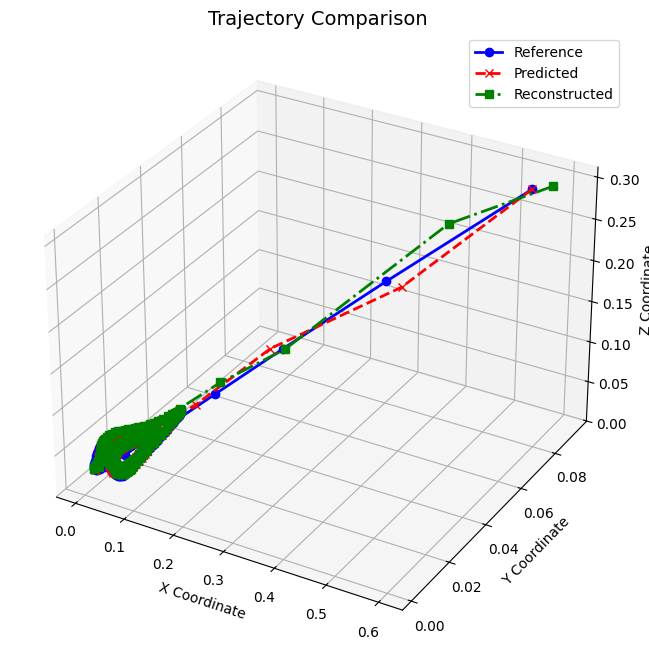

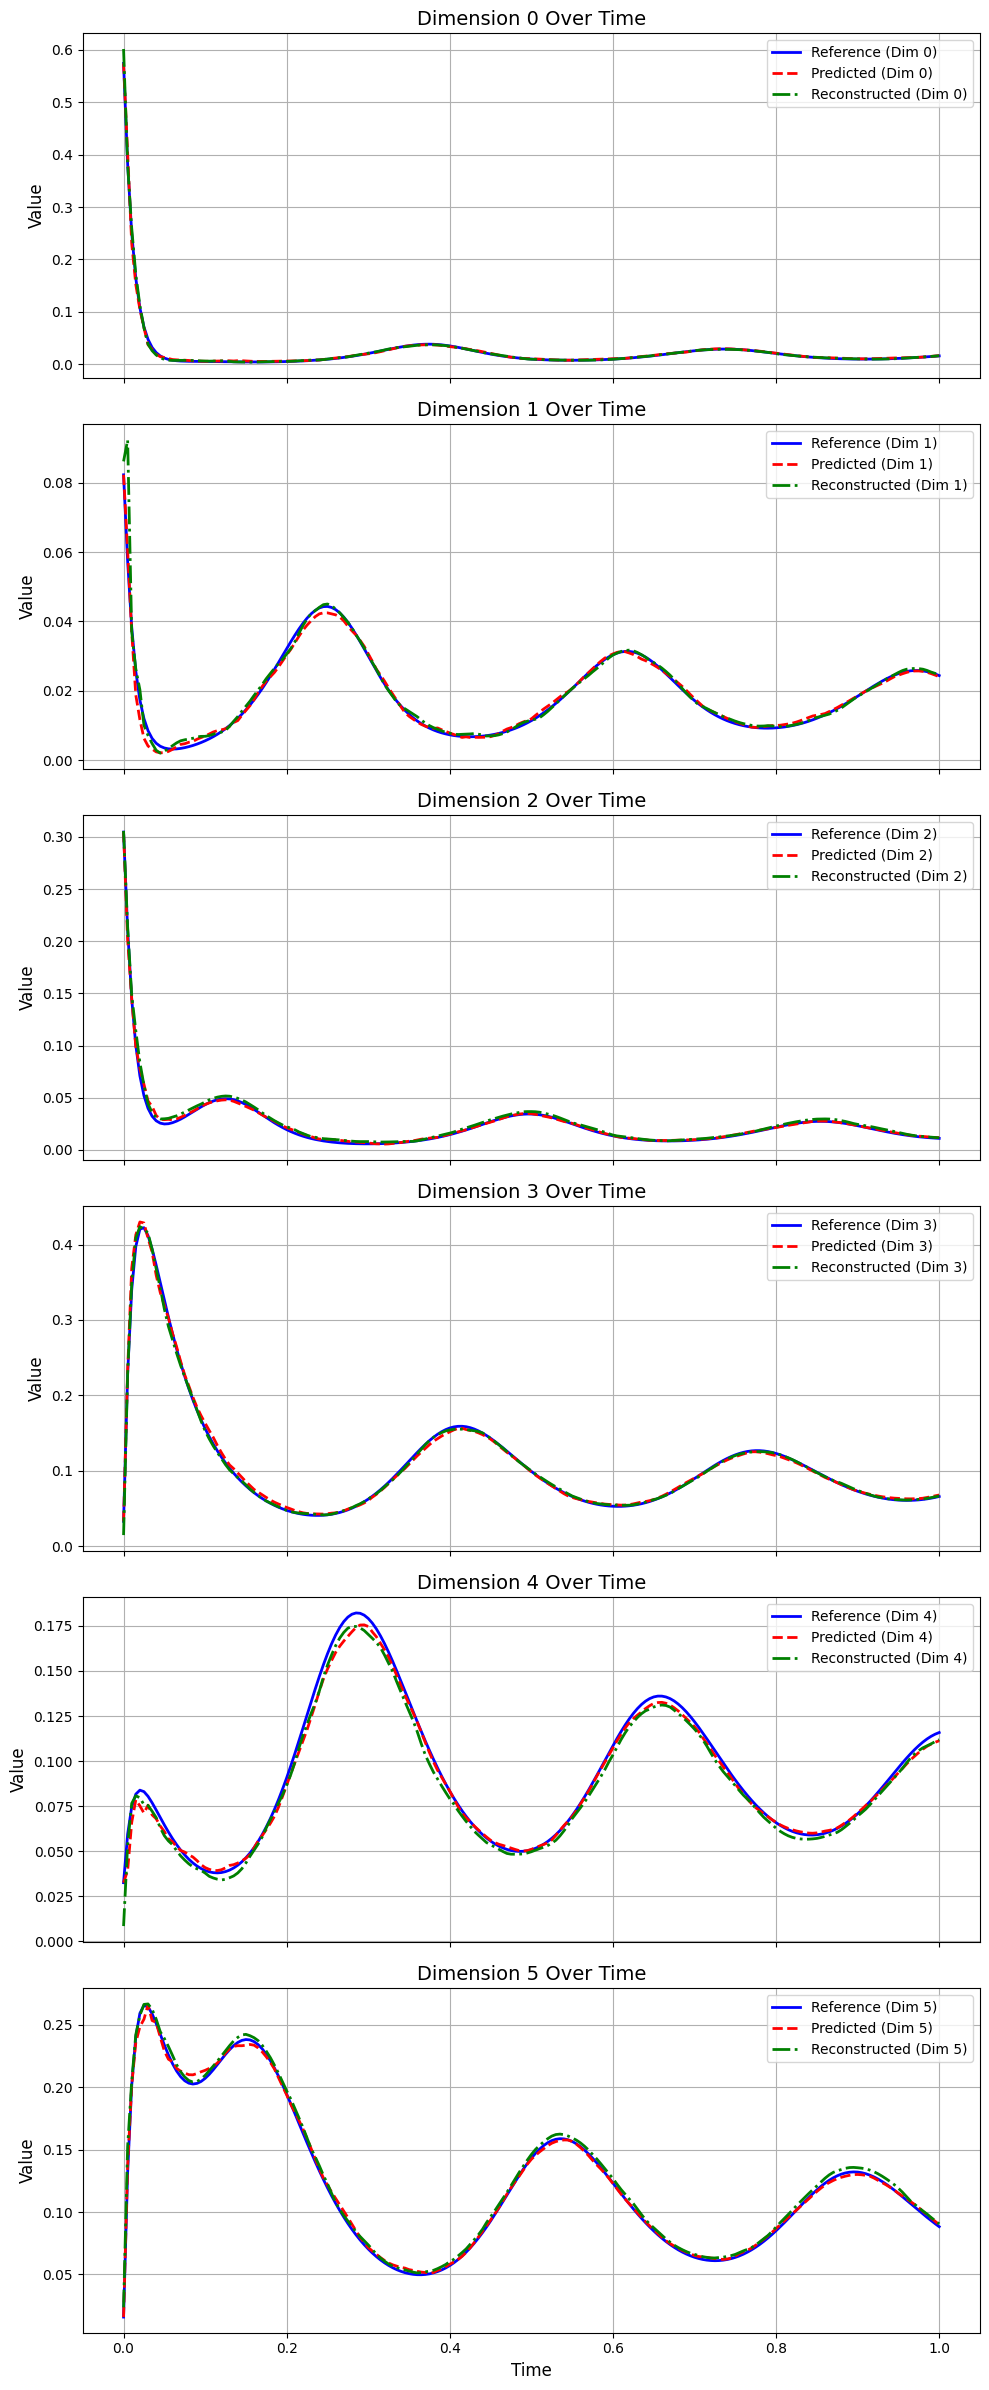

In [14]:
# for saving the results first

# Get a test sample
traj = preprocessed_data["Xtest"][5].to(device)

# Get reconstructed trajectory
model.eval()
with torch.no_grad():
    Y, reconstructed_traj = model.ae(traj)


# Get predicted trajectory
predicted_traj = trainer_AFT.predict_new(X0=traj[0], steps=len(traj)-1)

# Convert to numpy for plotting
traj = traj.cpu().detach().numpy()
reconstructed_traj = reconstructed_traj.cpu().detach().numpy()
predicted_traj = predicted_traj.cpu().detach().numpy()

# Plot trajectories
plot_trajectories(traj[:,:3], predicted_traj[:,:3], reconstructed_traj[:,:3], folder_path=folder_path,save=True)
plot_trajectory_comparison(traj, predicted_traj, reconstructed_traj, folder_path=folder_path,save=True)

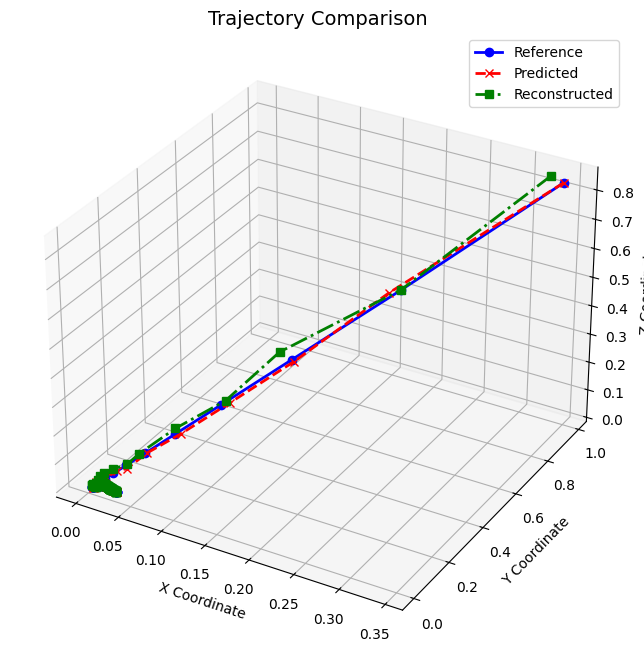

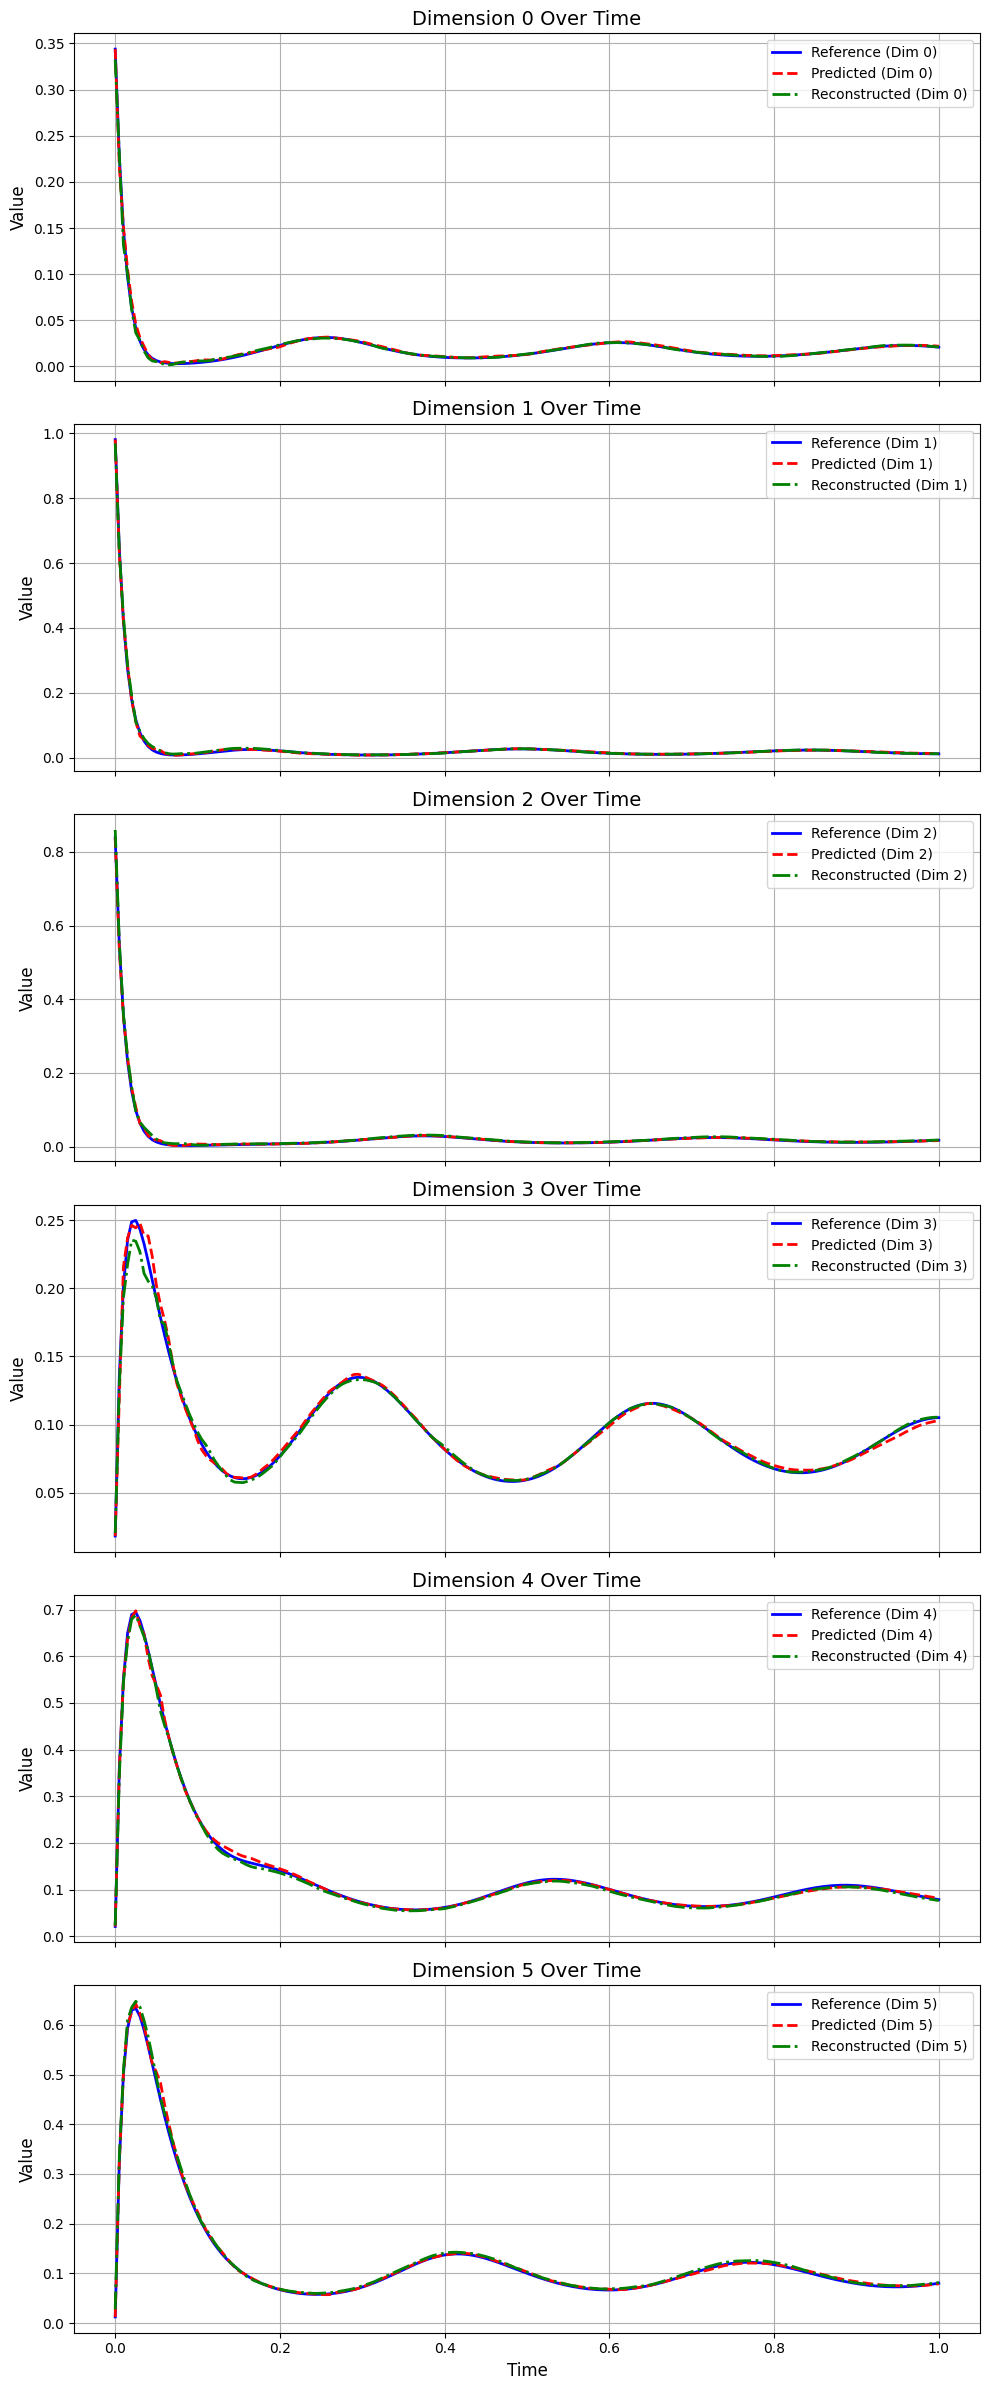

In [15]:
# Get a test sample
traj = preprocessed_data["Xtest"][8].to(device)

# Get reconstructed trajectory
model.eval()
with torch.no_grad():
    Y, reconstructed_traj = model.ae(traj)


# Get predicted trajectory
predicted_traj = trainer_AFT.predict_new(X0=traj[0], steps=len(traj)-1)

# Convert to numpy for plotting
traj = traj.cpu().detach().numpy()
reconstructed_traj = reconstructed_traj.cpu().detach().numpy()
predicted_traj = predicted_traj.cpu().detach().numpy()

# Plot trajectories
plot_trajectories(traj[:,:3], predicted_traj[:,:3], reconstructed_traj[:,:3], folder_path=folder_path,save=False)
plot_trajectory_comparison(traj, predicted_traj, reconstructed_traj, folder_path=folder_path,save=False)

### Long Term Prediction on the Repressilator up to 1000 timestep

Generating 100 trajectories...


  0%|          | 0/100 [00:00<?, ?it/s]/var/folders/5_/hq2ly88s2fxbtph44558kg8m0000gn/T/ipykernel_6272/766361078.py:38: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  trajectories[i] = traj
100%|██████████| 100/100 [00:00<00:00, 556.87it/s]


Evaluating model: Model 100_AFT


100%|██████████| 100/100 [00:11<00:00,  8.87it/s]


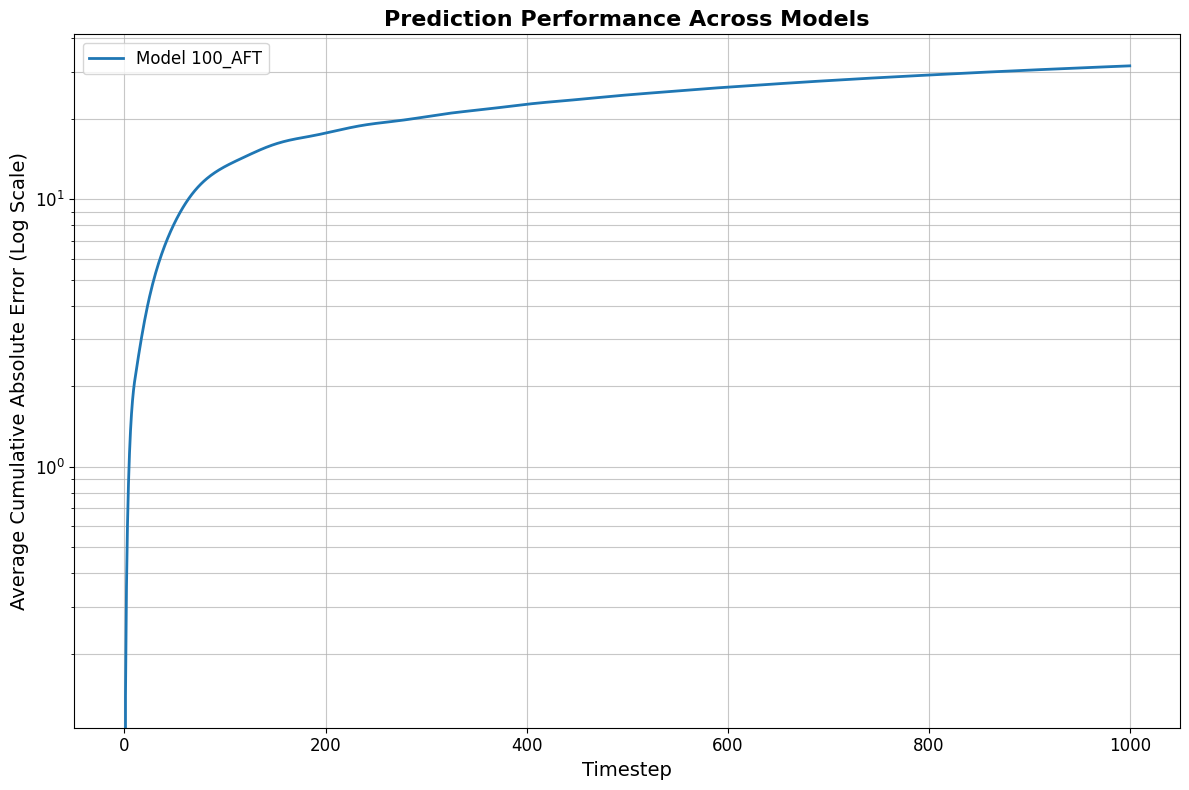

In [16]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm
from utils.data_loader import RepressilatorModel
import os

def generate_dataset(num_trajectories=1000, time_points=1001, time_span=1250):
    """
    Generate a dataset of multiple trajectories from the Repressilator model.
    
    Args:
        num_trajectories: Number of trajectories to generate
        time_points: Number of time points in each trajectory
        time_span: Total time span for simulation
        
    Returns:
        trajectories: numpy array of shape (num_trajectories, time_points, 6)
        times: array of time points used for simulation
    """
    print(f"Generating {num_trajectories} trajectories...")
    trajectories = np.zeros((num_trajectories, time_points, 6))
    times = np.linspace(0, time_span, time_points)
    
    for i in tqdm(range(num_trajectories)):
        # Random initial conditions
        y0 = np.random.rand(6) * 100
        
        # Create model and simulate
        repressilator_model = RepressilatorModel(y0=y0)
        parameters = args.data_parameters
        traj = repressilator_model.simulate(parameters, times)
        
        # Normalize
        traj = traj/data_handler.Xscale
        
        # Store trajectory
        trajectories[i] = traj
        
    return trajectories, times

def evaluate_models(trajectories, models_dict, device="cuda"):
    """
    Evaluate multiple models on the generated trajectories using absolute cumulative error.
    
    Args:
        trajectories: numpy array of shape (num_trajectories, time_points, 6)
        models_dict: dictionary containing model and trainer pairs
        device: device to run computations on
        
    Returns:
        results: dictionary with evaluation metrics for each model
    """
    num_trajectories, time_points, _ = trajectories.shape
    results = {}
    
    for model_name, (_, trainer) in models_dict.items():
        print(f"Evaluating model: {model_name}")
        
        # Initialize arrays to store losses
        prediction_errors = np.zeros((num_trajectories, time_points))
        cumulative_errors = np.zeros((num_trajectories, time_points))
        
        # Evaluate each trajectory
        for i in tqdm(range(num_trajectories)):
            # Convert to tensor
            traj = torch.tensor(trajectories[i], dtype=torch.float32).to(device)
            
            # Get predicted trajectory
            predicted_traj = trainer.predict_new(X0=traj[0], steps=len(traj)-1)
            
            # Convert to numpy for error calculation
            traj_np = traj.cpu().detach().numpy()
            predicted_traj_np = predicted_traj.cpu().detach().numpy()
            
            # Calculate absolute error at each time step and make it cumulative
            cumulative_error = 0
            for t in range(time_points):
                # Single timestep absolute prediction error
                if t < len(predicted_traj_np):
                    # Mean absolute error across all state variables
                    error = np.mean(np.abs(traj_np[t] - predicted_traj_np[t]))
                    prediction_errors[i, t] = error
                    
                    # Add to cumulative error
                    cumulative_error += error
                    cumulative_errors[i, t] = cumulative_error
        
        # Calculate average errors across all trajectories
        avg_prediction_error = np.mean(prediction_errors, axis=0)
        avg_cumulative_error = np.mean(cumulative_errors, axis=0)
        
        # Store results
        results[model_name] = {
            'avg_prediction_error': avg_prediction_error,
            'avg_cumulative_error': avg_cumulative_error
        }
    
    return results

def plot_results(results, folder_path):
    """
    Plot the average cumulative absolute error for each model using a log scale.
    
    Args:
        results: dictionary with evaluation metrics for each model
        folder_path: path to save the plot
    """
    plt.figure(figsize=(12, 8))
    
    # Get the number of timesteps from the first model result
    timesteps = len(next(iter(results.values()))['avg_cumulative_error'])
    timestep_indices = np.arange(timesteps)
    
    # Define a color cycle for models
    colors = plt.cm.tab10(np.linspace(0, 1, len(results)))
    
    # Plot cumulative absolute errors with log scale on y-axis
    for i, (model_name, metrics) in enumerate(results.items()):
        plt.semilogy(timestep_indices, metrics['avg_cumulative_error'], 
                     label=model_name, color=colors[i], linewidth=2)
    
    plt.xlabel('Timestep', fontsize=14)
    plt.ylabel('Average Cumulative Absolute Error (Log Scale)', fontsize=14)
    plt.title('Prediction Performance Across Models', fontsize=16, fontweight='bold')
    plt.legend(fontsize=12)
    plt.grid(True, which="both", ls="-", alpha=0.7)
    plt.tick_params(axis='both', which='major', labelsize=12)
    
    plt.tight_layout()
    
    # Make sure folder exists
    os.makedirs(folder_path, exist_ok=True)
    
    plt.savefig(os.path.join(folder_path, 'model_prediction_comparison_log.png'), dpi=300)
    plt.show()

def evaluate_repressilator_models(models_trainers_dict, num_trajectories=1000, 
                                 time_points=1001, time_span=200, 
                                 device="cuda", folder_path="results", 
                                 save_dataset=False, save_results=False):
    """
    Main function to evaluate any number of model and trainer pairs on Repressilator trajectories,
    focusing on absolute cumulative prediction error.
    
    Args:
        models_trainers_dict: Dictionary with format {model_name: (model, trainer), ...}
        num_trajectories: Number of trajectories to generate
        time_points: Number of time points in each trajectory
        time_span: Total time span for simulation
        device: Device to run computations on
        folder_path: Path to save results and plots
        save_dataset: Whether to save the generated dataset
        save_results: Whether to save the evaluation results
        
    Returns:
        trajectories: Generated trajectories
        results: Evaluation results dictionary
    """
    # Generate dataset
    trajectories, times = generate_dataset(
        num_trajectories=num_trajectories, 
        time_points=time_points, 
        time_span=time_span
    )
    
    # Save the dataset if requested
    if save_dataset:
        # Make sure folder exists
        os.makedirs(folder_path, exist_ok=True)
        np.save(os.path.join(folder_path, 'repressilator_trajectories.npy'), trajectories)
        np.save(os.path.join(folder_path, 'repressilator_times.npy'), times)
        print(f"Dataset saved to {folder_path}")
    
    # Evaluate models
    results = evaluate_models(trajectories, models_trainers_dict, device)
    
    # Plot results
    plot_results(results, folder_path)
    
    # Save the results if requested
    if save_results:
        # Make sure folder exists
        os.makedirs(folder_path, exist_ok=True)
        np.save(os.path.join(folder_path, 'prediction_evaluation_results.npy'), results)
        print(f"Evaluation results saved to {folder_path}")
    
    return trajectories, results

# Example usage:
if __name__ == "__main__":
    # Create a dictionary of models and trainers
    # You can add any number of model-trainer pairs
    models_trainers_dict = {
        "Model 100_AFT": (model, trainer_AFT),
    }
    
    # Evaluate all models
    trajectories, results = evaluate_repressilator_models(
        models_trainers_dict, 
        num_trajectories=100,  # Use more trajectories for final evaluation
        device=device,
        folder_path=folder_path
    )

## Sample Trajectory for Long Term Prediction

## The generated data

In [54]:
from utils.data_loader import RepressilatorModel

#y = [15, 20, 80,  90, 30, 70]
y = np.random.rand(6) * 100
#y = y = [70, 10, 3,  65, 12, 3]
print('Initial conditions:', y)
Repressilator_model = RepressilatorModel(y0=y)

parameters = args.data_parameters
times =  np.linspace(0,1250, 1001)
traj = Repressilator_model.simulate(parameters, times)

traj = traj/data_handler.Xscale


Initial conditions: [40.32204721 75.8746931  71.69290017 98.73261748 27.80850486  0.37936724]


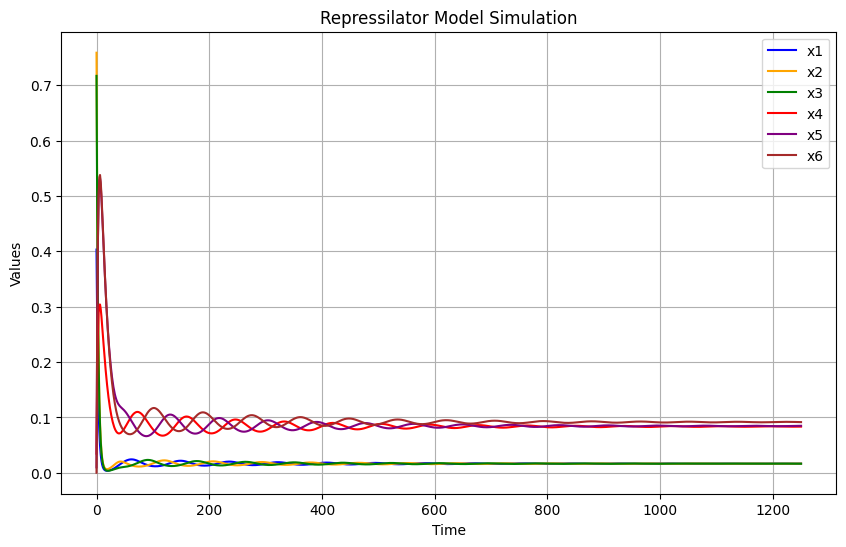

In [55]:
# visualize each dimension 

plt.figure(figsize=(10, 6))
plt.plot(times, traj[:, 0], label='x1', color='blue')
plt.plot(times, traj[:, 1], label='x2', color='orange')
plt.plot(times, traj[:, 2], label='x3', color='green')
plt.plot(times, traj[:, 3], label='x4', color='red')
plt.plot(times, traj[:, 4], label='x5', color='purple')
plt.plot(times, traj[:, 5], label='x6', color='brown')
plt.xlabel('Time')
plt.ylabel('Values')
plt.title('Repressilator Model Simulation')
plt.legend()
plt.grid()
plt.show()

/var/folders/5_/hq2ly88s2fxbtph44558kg8m0000gn/T/ipykernel_6272/509345187.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  traj = torch.tensor(traj, dtype=torch.float32).to(device)


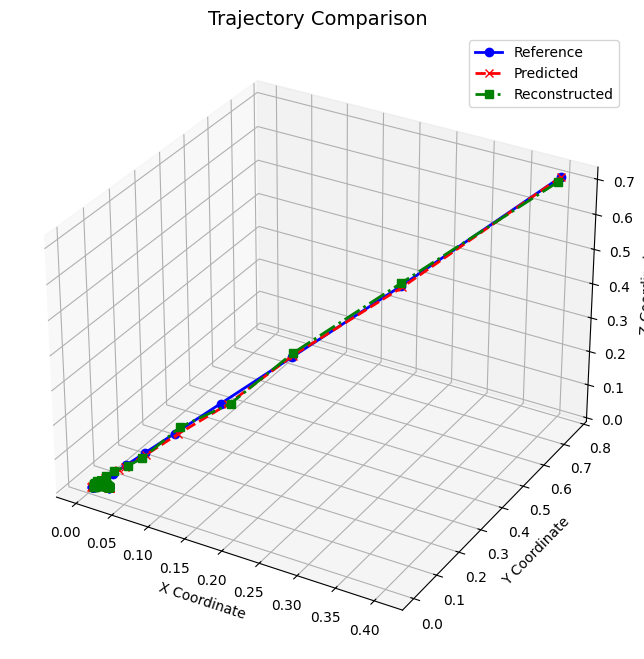

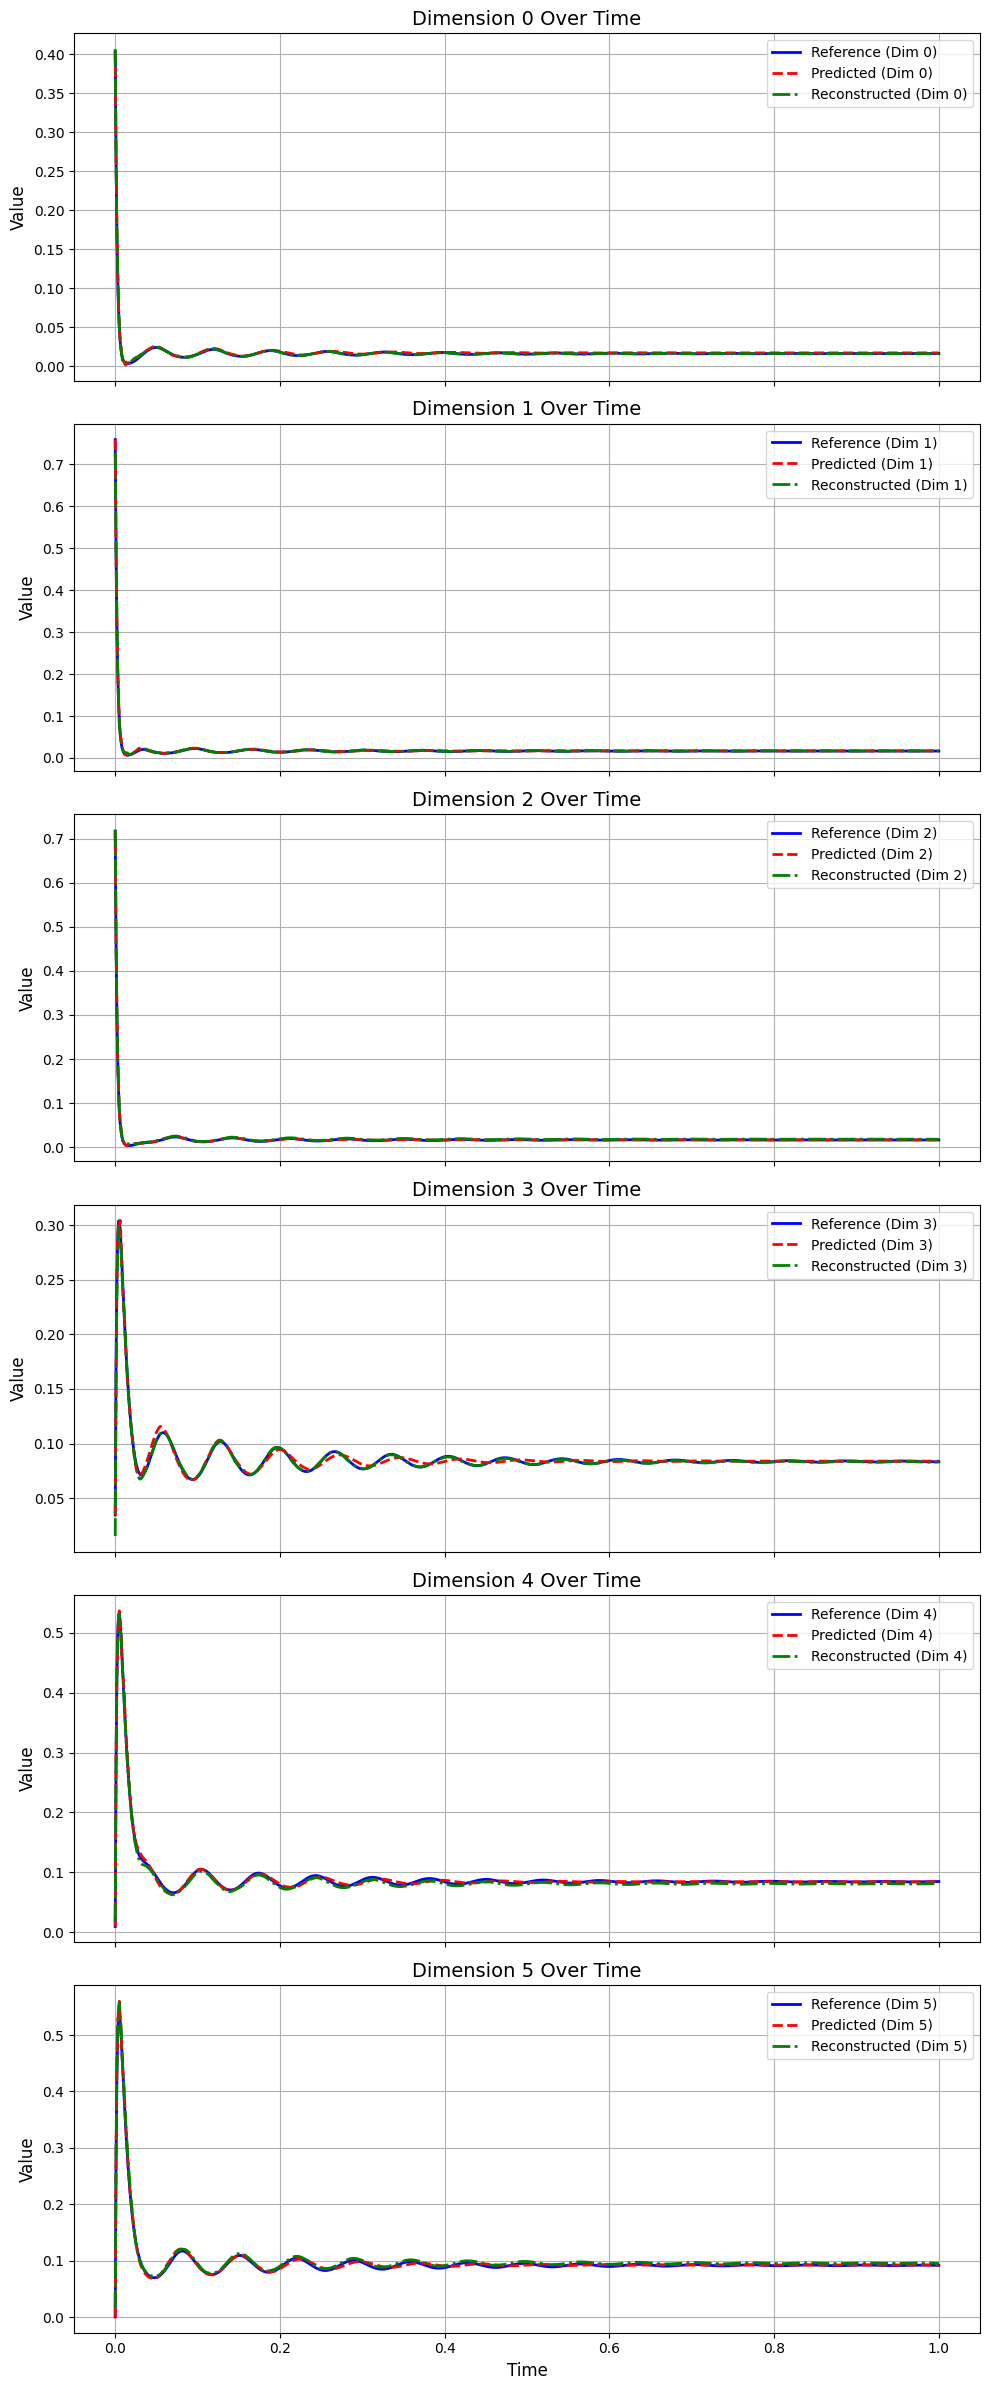

In [56]:
# traj as tensor
traj = torch.tensor(traj, dtype=torch.float32).to(device)

# Get reconstructed trajectory
model.eval()
with torch.no_grad():
    Y, reconstructed_traj = model.ae(traj)


# Get predicted trajectory
predicted_traj = trainer_AFT.predict_new(X0=traj[0], steps=len(traj)-1)

# Convert to numpy for plotting
traj = traj.cpu().detach().numpy()
reconstructed_traj = reconstructed_traj.cpu().detach().numpy()
predicted_traj = predicted_traj.cpu().detach().numpy()

# Plot trajectories
plot_trajectories(traj[:,:3], predicted_traj[:,:3], reconstructed_traj[:,:3], folder_path=folder_path,save=False)
plot_trajectory_comparison(traj, predicted_traj, reconstructed_traj, folder_path=folder_path,save=False)


## Eigenvalues Visualization

Compute and visualize the eigenvalues of the Koopman operator on a unit circle.

Eigenvalues:
[ 0.9996668 -0.02525315j  0.9996668 +0.02525315j  0.9988119 -0.0490134j
  0.9988119 +0.0490134j   0.99583614-0.09048017j  0.99583614+0.09048017j
  0.9790761 +0.20353146j  0.9790761 -0.20353146j  0.9621437 -0.27257717j
  0.9621437 +0.27257717j  0.94629526-0.32324567j  0.94629526+0.32324567j
  0.92794025-0.37271762j  0.92794025+0.37271762j  0.9140861 -0.4055266j
  0.9140861 +0.4055266j   0.87030345-0.49250355j  0.87030345+0.49250355j
  0.85715085-0.51506037j  0.85715085+0.51506037j  0.8073147 -0.590226j
  0.8073147 +0.590226j    0.7709596 +0.63688374j  0.7709596 -0.63688374j
  0.7393762 -0.6732956j   0.7393762 +0.6732956j   0.6976696 -0.7165463j
  0.6976696 +0.7165463j   0.6386232 -0.769547j    0.6386232 +0.769547j
  0.5693815 +0.8220245j   0.5693815 -0.8220245j   0.5317236 -0.84692675j
  0.5317236 +0.84692675j  0.49550676-0.8686011j   0.49550676+0.8686011j
  0.44794333-0.8940442j   0.44794333+0.8940442j   0.40428013-0.91463673j
  0.40428013+0.91463673j  0.2809775 +0.9597031

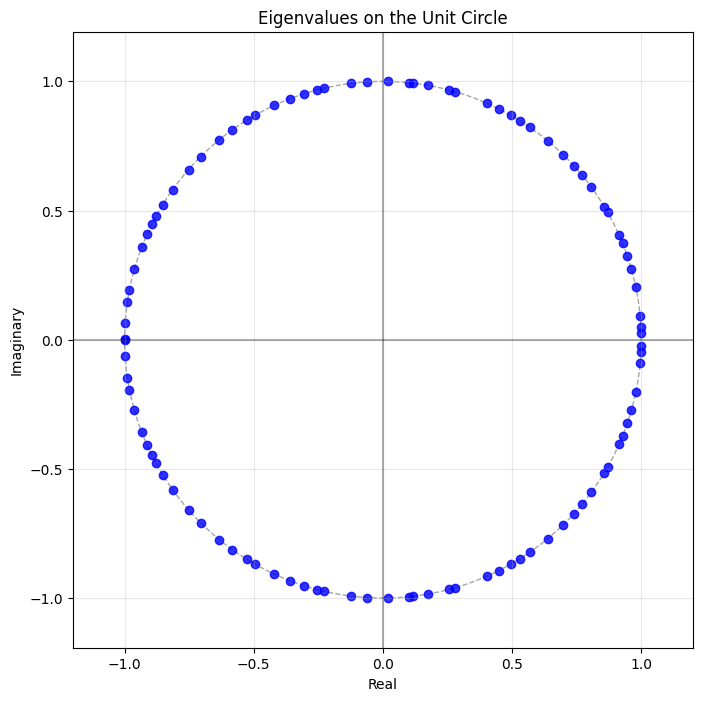

In [20]:
# Compute eigenvalues
eigenvalues, eigenvectors = torch.linalg.eig(model.knet.net.weight)
eigenvalues = eigenvalues.cpu().detach().numpy()
idx = np.argsort(eigenvalues.real)[::-1]
eigenvalues = eigenvalues[idx]

# Print eigenvalues
print('Eigenvalues:')
print(eigenvalues)

# Plot eigenvalues on unit circle
plot_eigenvalues_on_unit_circle(eigenvalues, folder_path)

print(f"Training and evaluation completed. Results saved in {folder_path}")